<a href="https://colab.research.google.com/github/Andalejo1109/Retiro-portafolio/blob/main/Retiro_portafolio_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ¿Cuánto portafolio necesitas para retirar $1.000 al mes?

Backtest de la asignación **SPYG 33% · SMH 21% · BRK.B 21% · IEMG 16% · VTI 9%**.

- Año 1: **$1.000 / mes** ($12.000 al año).
- Desde el año 2 el retiro mensual sube **3% anual** ($1.030, $1.060.90, …).
- Tres patrimonios iniciales: $150k, $300k, $500k.

No es asesoría de inversión. Ejercicio educativo sobre riesgo de secuencia.

## 1. Instalar dependencias

In [4]:
!pip -q install yfinance matplotlib pandas numpy pillow

## 2. Cargar el simulador

Si abriste el notebook **desde GitHub**, clona el repo. Si subiste los archivos a Colab, usa el `.py` local.

In [5]:
from pathlib import Path

# Cambia esto cuando publiques el repo:
GITHUB_USER = "Andalejo1109"
GITHUB_REPO = "retiro-portafolio"

if Path("simular_retiro.py").exists():
    print("Usando simular_retiro.py local")
else:
    print("Clonando repositorio…")
    # Si el clone falla, sube simular_retiro.py a Colab (panel izquierdo) y vuelve a correr.
    import subprocess, sys
    url = f"https://github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
    r = subprocess.run(["git", "clone", "--depth", "1", url], capture_output=True, text=True)
    print(r.stdout or r.stderr)
    py = Path(GITHUB_REPO) / "simular_retiro.py"
    if py.exists():
        Path("simular_retiro.py").write_text(py.read_text())
        print("Copiado simular_retiro.py")
    else:
        raise FileNotFoundError(
            "No está simular_retiro.py. Súbelo a esta sesión de Colab o publica el repo."
        )

Usando simular_retiro.py local


## 3. Parámetros

In [6]:
START = "2006-09-01"   # alternativa: "2010-01-01"
END   = "2026-08-28"
BASE  = 1000.0         # US$ mensuales en el año 1
COLA  = 0.03           # +3% anual desde el año 2
MAKE_GIF = True        # False si solo quieres el PNG

## 4. Simular

In [7]:
from IPython.display import Image, display
from simular_retiro import download_prices, simulate, print_summary, save_static, save_gif
from pathlib import Path

out = Path("output")
out.mkdir(exist_ok=True)

print("Descargando precios (Yahoo Finance)…")
prices = download_prices(START, END)
df, meta = simulate(prices, base_withdrawal=BASE, cola=COLA)
print_summary(df, meta)

stem = f"retiro_{int(BASE)}_{int(COLA*100)}pct_{START[:4]}"
png = save_static(df, meta, out / f"{stem}.png")
df.to_csv(out / f"{stem}.csv")
print("PNG:", png)

gif = None
if MAKE_GIF:
    gif = save_gif(df, meta, out / f"{stem}.gif", n_frames=64)
    print("GIF:", gif)

Descargando precios (Yahoo Finance)…
Periodo     : 2006-09-01 → 2026-08-27
COLA        : 3.0% anual desde el año 2
Retiro año 1: $1,000/mes
Retiro final: $1,754/mes
Gastado     : $322,444
--------------------------------------------------------
Nivel           Final       Mínimo     Retirado           Estado
150k          USD 48K      USD 44K     USD 322K        sobrevive
300k        USD 1.97M     USD 165K     USD 322K        sobrevive
500k        USD 4.53M     USD 288K     USD 322K        sobrevive
PNG: output/retiro_1000_3pct_2006.png
GIF: output/retiro_1000_3pct_2006.gif


## 5. Gráfico

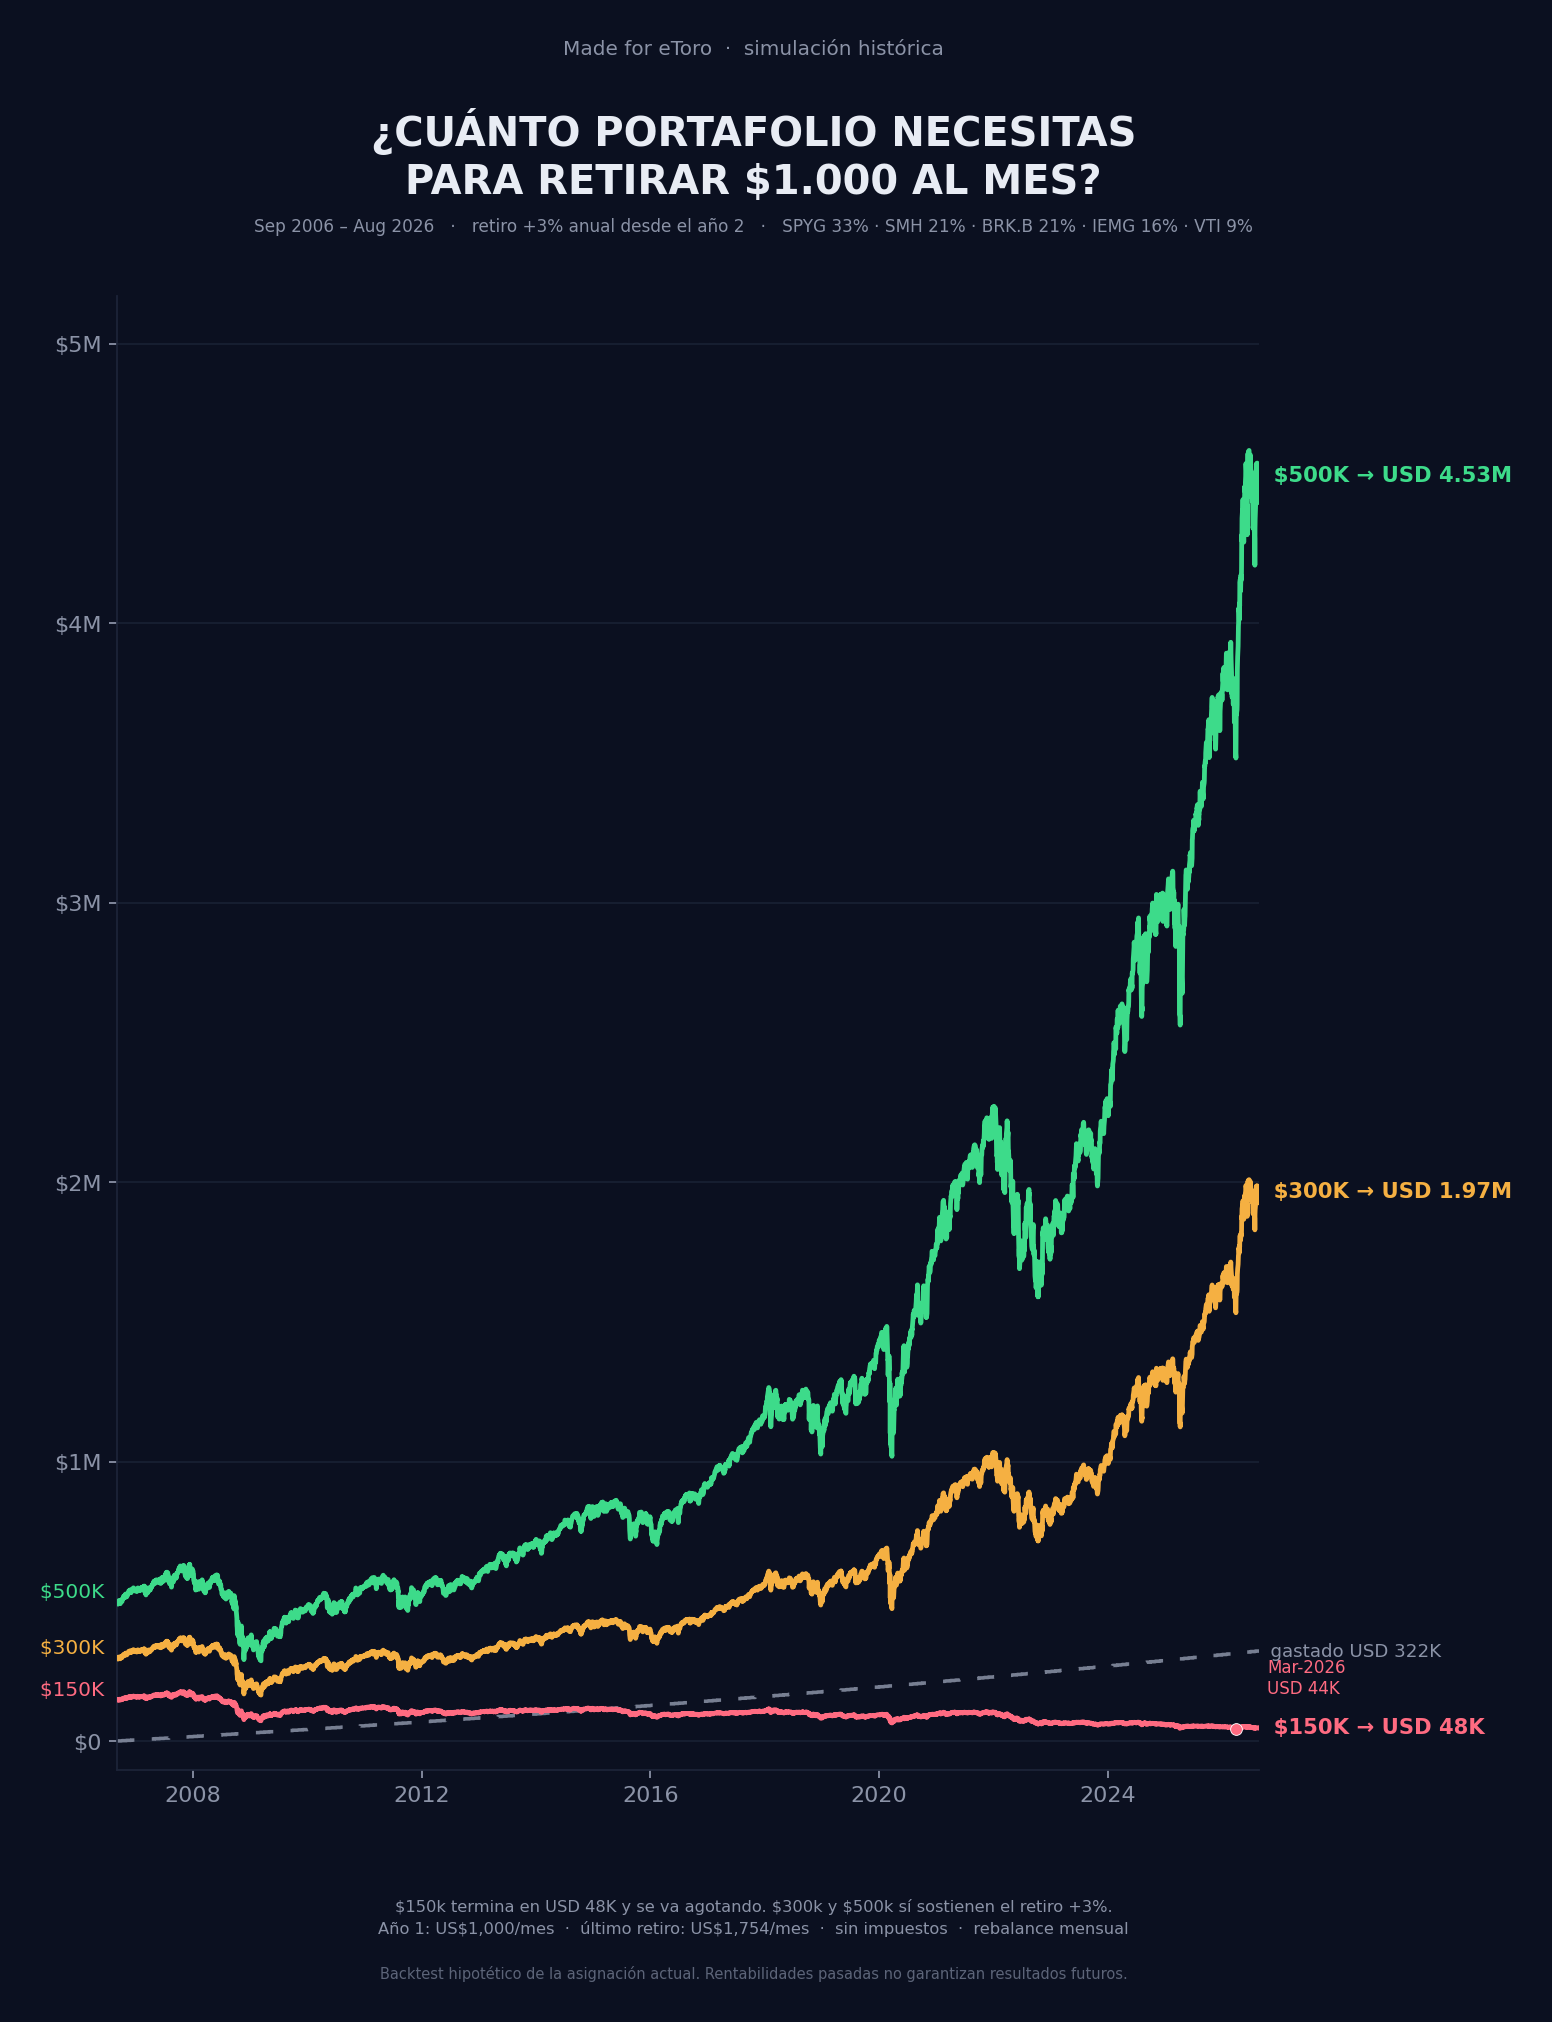

In [8]:
display(Image(filename=str(png)))

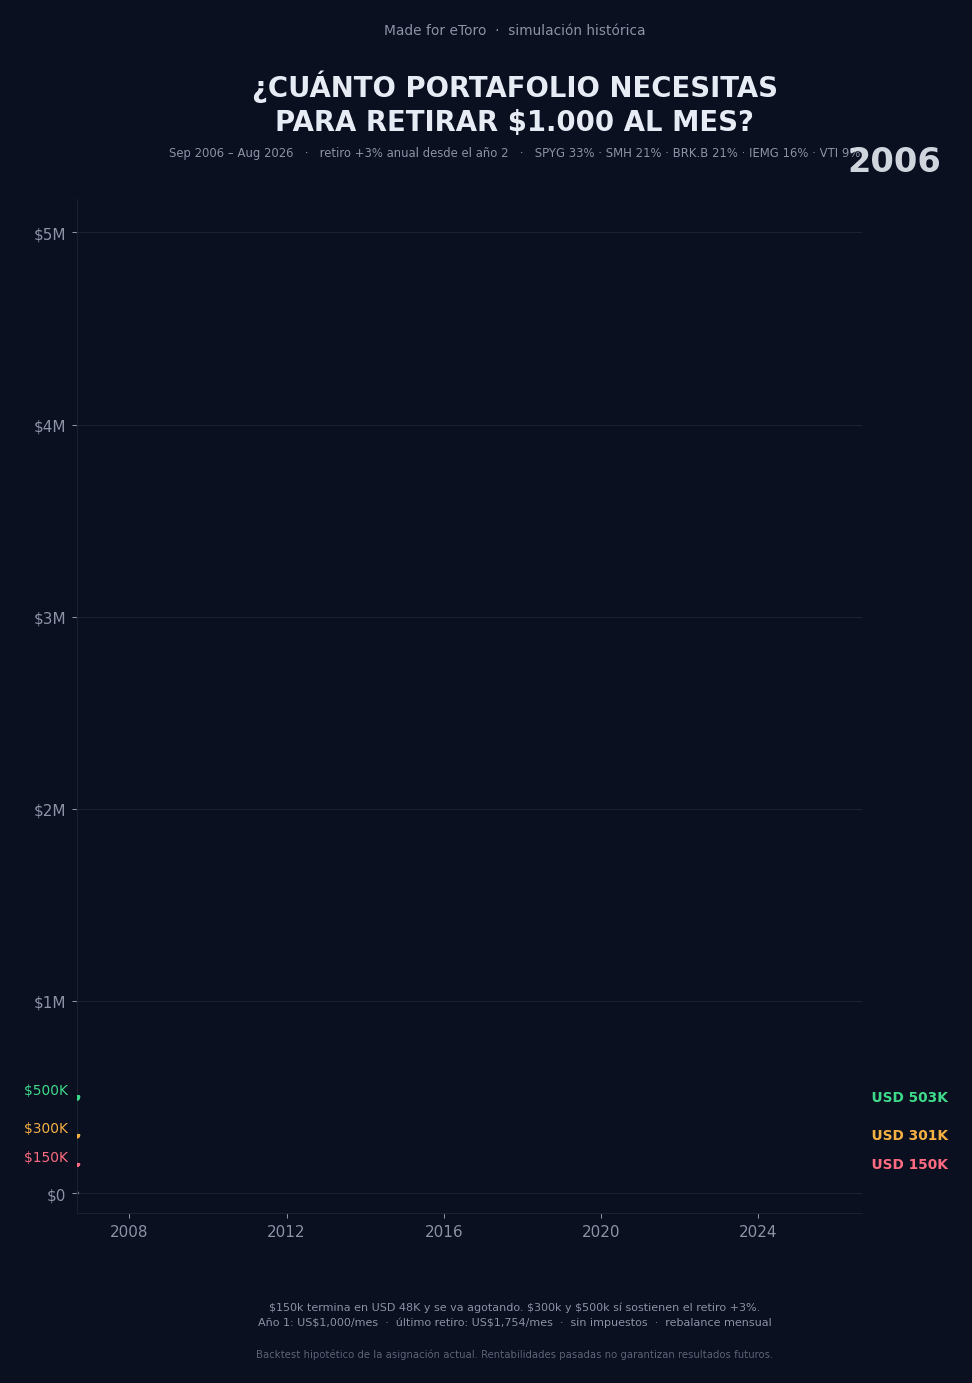

In [9]:
if gif is not None:
    display(Image(filename=str(gif)))

## 6. Descargar archivos

En Colab, esta celda los baja a tu computadora.

In [10]:
try:
    from google.colab import files
    files.download(str(png))
    if gif is not None:
        files.download(str(gif))
    files.download(str(out / f"{stem}.csv"))
except ImportError:
    print("No estás en Colab: los archivos ya están en ./output")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>